c:\lab\llm-workspace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


실행 장치: cpu


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 11223.69it/s]


CLIP 모델 로드 완료
생성된 텍스트 프롬프트 수: 40

프롬프트 예시
- a handwritten digit 0
- a black and white image of the digit 0
- a grayscale image showing the number 0
- a simple handwritten number 0
- a handwritten digit 1
- a black and white image of the digit 1

프롬프트별 텍스트 임베딩 형태:
torch.Size([40, 512])

숫자별 텍스트 임베딩 형태:
torch.Size([10, 512])

MNIST 테스트 샘플 수: 1000


Zero-shot 분류 진행: 100%|██████████| 32/32 [01:16<00:00,  2.38s/it]



MNIST CLIP Zero-shot 분류 결과
전체 평가 이미지 수: 1000
정답 이미지 수: 325
오답 이미지 수: 675
정확도: 32.50%

숫자별 분류 결과
숫자 0: 106/106 (100.00%)
숫자 1: 5/117 (4.27%)
숫자 2: 0/109 (0.00%)
숫자 3: 0/91 (0.00%)
숫자 4: 33/86 (38.37%)
숫자 5: 70/91 (76.92%)
숫자 6: 10/105 (9.52%)
숫자 7: 82/95 (86.32%)
숫자 8: 19/102 (18.63%)
숫자 9: 0/98 (0.00%)

오분류 이미지 수: 675


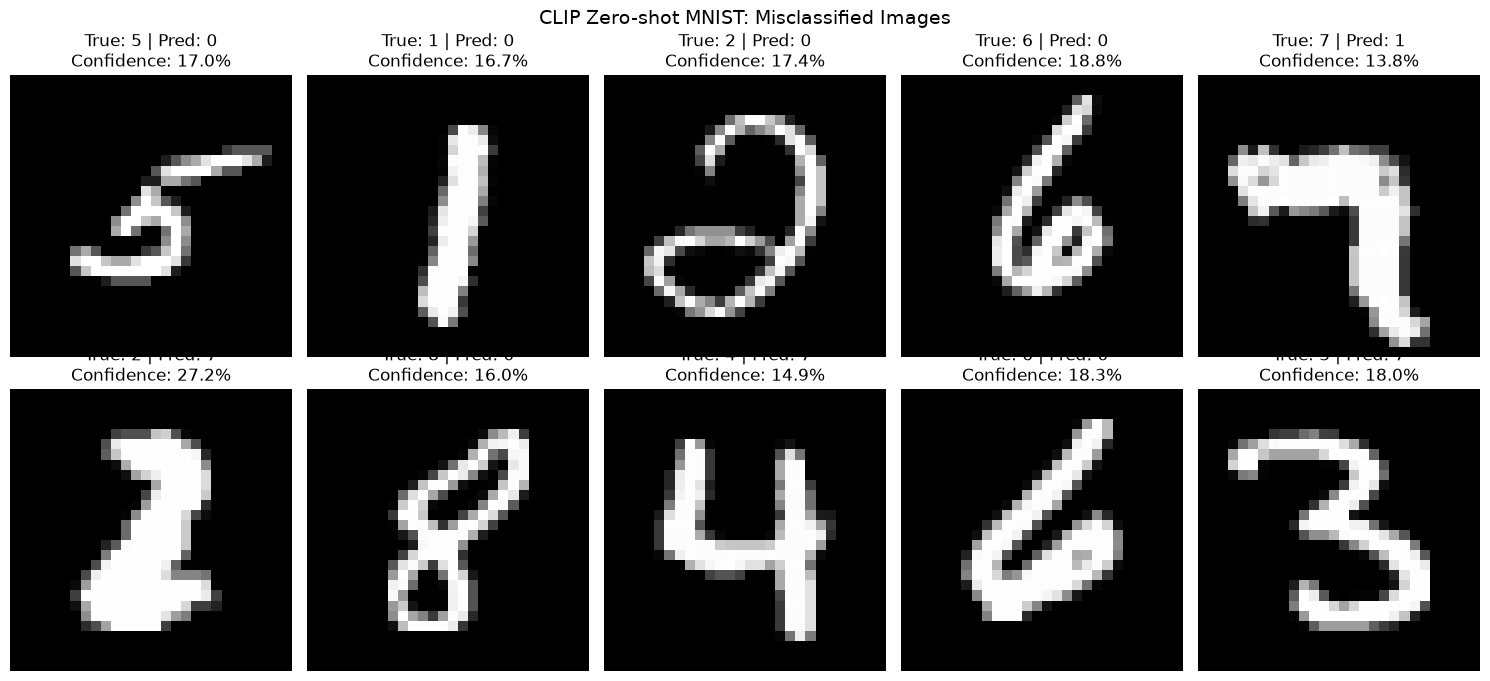


예측 결과 예시
이미지 01 | 정답: 5 | 예측: 0 | 일치: False
이미지 02 | 정답: 5 | 예측: 5 | 일치: True
이미지 03 | 정답: 0 | 예측: 0 | 일치: True
이미지 04 | 정답: 7 | 예측: 7 | 일치: True
이미지 05 | 정답: 1 | 예측: 0 | 일치: False
이미지 06 | 정답: 8 | 예측: 8 | 일치: True
이미지 07 | 정답: 5 | 예측: 5 | 일치: True
이미지 08 | 정답: 0 | 예측: 0 | 일치: True
이미지 09 | 정답: 2 | 예측: 0 | 일치: False
이미지 10 | 정답: 6 | 예측: 0 | 일치: False


In [1]:

# ============================================================
# MNIST 손글씨 숫자 분류: CLIP Zero-shot Classification
# ============================================================
#
# [프로젝트 목표]
# 1. 사전 학습된 CLIP 모델을 불러온다.
# 2. 숫자 0~9에 대한 텍스트 임베딩을 생성한다.
# 3. MNIST 손글씨 이미지를 CLIP 이미지 인코더로 변환한다.
# 4. 이미지 임베딩과 텍스트 임베딩의 유사도를 계산한다.
# 5. 가장 유사도가 높은 숫자를 예측한다.
# 6. 정확도와 오분류 이미지를 확인한다.
#
# [Zero-shot이란?]
# MNIST 데이터로 모델을 추가 학습하지 않고,
# 사전 학습된 CLIP의 이미지-텍스트 유사도를 이용하는 방식이다.
# ============================================================


# ------------------------------------------------------------
# 1. 라이브러리 불러오기
# ------------------------------------------------------------

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from transformers import CLIPModel, CLIPProcessor
from tqdm.auto import tqdm


# ------------------------------------------------------------
# 2. 재현성을 위한 난수 시드 설정
# ------------------------------------------------------------

# 동일한 난수 시드를 사용하면 데이터 샘플링 결과를
# 가능한 한 동일하게 재현할 수 있다.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# 3. 실행 환경 설정
# ------------------------------------------------------------

# CUDA GPU가 있으면 GPU를 사용하고,
# GPU가 없으면 CPU를 사용한다.
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"실행 장치: {device}")


# ------------------------------------------------------------
# 4. CLIP 모델과 Processor 불러오기
# ------------------------------------------------------------

# openai/clip-vit-base-patch32:
# 이미지와 텍스트를 공통 임베딩 공간으로 변환하는 CLIP 모델이다.
MODEL_NAME = "openai/clip-vit-base-patch32"

# CLIPModel:
# 이미지 인코더, 텍스트 인코더, 투영 계층 등을 포함한다.
model = CLIPModel.from_pretrained(MODEL_NAME)

# CLIPProcessor:
# 텍스트 토큰화와 이미지 전처리를 담당한다.
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

# 모델을 CPU 또는 GPU로 이동한다.
model = model.to(device)

# 추론 모드로 설정한다.
# Dropout 등의 학습용 동작을 비활성화한다.
model.eval()

# 모델의 가중치를 추가 학습하지 않는다.
for parameter in model.parameters():
    parameter.requires_grad = False

print("CLIP 모델 로드 완료")


# ------------------------------------------------------------
# 5. 숫자 0~9에 대한 텍스트 프롬프트 생성
# ------------------------------------------------------------

# CLIP은 숫자만 입력하는 것보다
# 자연어 문장으로 표현했을 때 유용한 경우가 있다.
#
# 같은 숫자라도 여러 문장으로 표현하여
# 텍스트 표현의 다양성을 확보한다.

templates = [
    "a handwritten digit {}",
    "a black and white image of the digit {}",
    "a grayscale image showing the number {}",
    "a simple handwritten number {}"
]
# 숫자별 프롬프트를 생성한다.
# 숫자 10개 × 프롬프트 3개 = 총 30개 문장이다.
all_prompts = []

for digit in range(10):
    for template in templates:
        prompt = template.format(digit)
        all_prompts.append(prompt)

print(f"생성된 텍스트 프롬프트 수: {len(all_prompts)}")

# 생성된 프롬프트 일부 확인
print("\n프롬프트 예시")

for prompt in all_prompts[:6]:
    print("-", prompt)


# ------------------------------------------------------------
# 6. 텍스트 임베딩 생성
# ------------------------------------------------------------

# 텍스트를 CLIP 모델이 처리할 수 있는 토큰으로 변환한다.
text_inputs = processor(
    text=all_prompts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

# 입력 데이터를 모델 실행 장치로 이동한다.
text_inputs = {
    key: value.to(device)
    for key, value in text_inputs.items()
}

with torch.inference_mode():

    # 텍스트 인코더를 실행한다.
    #
    # text_model은 BaseModelOutputWithPooling 형태의
    # 결과를 반환한다.
    #
    # 여기서 pooler_output은 텍스트 인코더의 출력이다.
    # CLIP의 text_projection을 통과시켜야 이미지 임베딩과
    # 비교할 수 있는 공통 임베딩 공간으로 변환된다.
    text_outputs = model.text_model(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs.get("attention_mask")
    )

    # 텍스트의 pooled representation을 추출한다.
    text_pooled = text_outputs.pooler_output

    # CLIP 텍스트 투영 계층을 적용한다.
    text_features = model.text_projection(text_pooled)

    # 각 텍스트 임베딩을 L2 정규화한다.
    # 정규화하면 각 벡터의 길이가 1이 된다.
    text_features = F.normalize(
        text_features,
        p=2,
        dim=-1
    )

# 현재 텍스트 임베딩 형태:
# [30, 512]
#
# 30: 숫자 10개 × 프롬프트 3개
# 512: CLIP 공통 임베딩 차원

print("\n프롬프트별 텍스트 임베딩 형태:")
print(text_features.shape)


# ------------------------------------------------------------
# 7. 숫자별 텍스트 임베딩 통합
# ------------------------------------------------------------

# 숫자 하나당 프롬프트가 3개이므로
# 각 숫자의 임베딩을 평균하여 대표 벡터를 만든다.
#
# 기존:
# [30, 512]
#
# reshape 후:
# [10, 3, 512]
#
# 프롬프트 3개를 평균한 후:
# [10, 512]

num_classes = 10
num_templates = len(templates)

text_features = text_features.reshape(
    num_classes,
    num_templates,
    -1
)

# 숫자별로 프롬프트 임베딩을 평균한다.
text_features = text_features.mean(dim=1)

# 평균 이후 벡터도 다시 정규화한다.
text_features = F.normalize(
    text_features,
    p=2,
    dim=-1
)

print("\n숫자별 텍스트 임베딩 형태:")
print(text_features.shape)

# 예상 형태: torch.Size([10, 512])


# ------------------------------------------------------------
# 8. MNIST 테스트 데이터셋 불러오기
# ------------------------------------------------------------

# MNIST는 0~9의 손글씨 숫자 이미지 데이터셋이다.
#
# 이미지는 기본적으로 28×28 크기의 흑백 이미지이며,
# CLIP Processor에서 RGB 변환 및 모델 입력 크기 조정을 수행한다.

transform = transforms.ToTensor()

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# 전체 테스트 데이터 대신 일부 데이터로 먼저 실험한다.
# 원하는 경우 1000을 5000 또는 10000으로 변경할 수 있다.
NUM_SAMPLES = min(1000, len(test_dataset))

# 데이터 일부를 무작위로 선택한다.
generator = torch.Generator().manual_seed(SEED)

sample_indices = torch.randperm(
    len(test_dataset),
    generator=generator
)[:NUM_SAMPLES].tolist()

test_subset = Subset(
    test_dataset,
    sample_indices
)

print(f"\nMNIST 테스트 샘플 수: {len(test_subset)}")


# ------------------------------------------------------------
# 9. DataLoader용 사용자 정의 collate 함수
# ------------------------------------------------------------

# MNIST 원본 이미지는 흑백 이미지이다.
#
# CLIP은 일반적으로 RGB 이미지로 학습되었으므로
# 각 이미지를 PIL 이미지로 변환하고 RGB로 변경한다.
#
# Processor가 이미지 크기 변경과 정규화를 수행하므로
# 여기서는 RGB 변환까지만 수행한다.

def collate_fn(batch):

    images = []
    labels = []

    for image_tensor, label in batch:

        # Tensor의 형태:
        # [1, 28, 28]
        #
        # PIL 이미지로 변환하기 위해
        # 채널 차원을 제거하고 NumPy 배열로 변환한다.
        image_array = (
            image_tensor.squeeze(0).numpy() * 255
        ).astype(np.uint8)

        # PIL 이미지를 만들고 RGB 3채널로 변환한다.
        from PIL import Image

        image = Image.fromarray(image_array).convert("RGB")

        images.append(image)
        labels.append(label)

    # 이미지는 PIL 이미지 리스트로,
    # 정답 레이블은 Tensor로 반환한다.
    return images, torch.tensor(labels, dtype=torch.long)


# 배치 단위로 데이터를 불러온다.
BATCH_SIZE = 32

test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)


# ------------------------------------------------------------
# 10. 이미지 임베딩 생성 및 Zero-shot 분류
# ------------------------------------------------------------

all_predictions = []
all_labels = []
all_images = []
all_probabilities = []

# 이미지와 텍스트의 유사도를 계산할 때 사용하는
# CLIP의 학습된 logit scale을 가져온다.
#
# exp(logit_scale)은 유사도 점수를 로짓으로 변환하는
# 스케일 값이다. 예측 클래스의 argmax는 스케일 적용
# 전후에 동일하다.
logit_scale = model.logit_scale.exp().detach()

with torch.inference_mode():

    for images, labels in tqdm(
        test_loader,
        desc="Zero-shot 분류 진행"
    ):

        # --------------------------------------------
        # 10-1. 이미지 전처리
        # --------------------------------------------

        # PIL 이미지 리스트를 CLIP 입력 Tensor로 변환한다.
        image_inputs = processor(
            images=images,
            return_tensors="pt"
        )

        pixel_values = image_inputs["pixel_values"].to(device)

        # --------------------------------------------
        # 10-2. 이미지 인코더 실행
        # --------------------------------------------

        # vision_model의 출력은 단순한 Tensor가 아니라
        # pooler_output 등을 포함하는 출력 객체이다.
        image_outputs = model.vision_model(
            pixel_values=pixel_values
        )

        # 이미지의 pooled representation을 추출한다.
        image_pooled = image_outputs.pooler_output

        # CLIP 이미지 투영 계층을 적용한다.
        # 텍스트 임베딩과 동일한 차원 및 공간으로 변환한다.
        image_features = model.visual_projection(image_pooled)

        # 이미지 임베딩 정규화
        image_features = F.normalize(
            image_features,
            p=2,
            dim=-1
        )

        # --------------------------------------------
        # 10-3. 이미지-텍스트 유사도 계산
        # --------------------------------------------

        # image_features:
        # [배치 크기, 512]
        #
        # text_features:
        # [10, 512]
        #
        # 행렬 곱 결과:
        # [배치 크기, 10]
        #
        # 각 이미지와 숫자 0~9의 텍스트 표현 간
        # 코사인 유사도에 해당하는 값을 계산한다.
        similarities = image_features @ text_features.T

        # CLIP의 logit scale을 적용한다.
        logits = similarities * logit_scale

        # 각 이미지에 대해 숫자 0~9의 확률 분포를 계산한다.
        probabilities = F.softmax(logits, dim=1)

        # 유사도 로짓이 가장 큰 숫자를 예측한다.
        predictions = logits.argmax(dim=1).cpu()

        # --------------------------------------------
        # 10-4. 결과 저장
        # --------------------------------------------

        all_predictions.extend(predictions.tolist())
        all_labels.extend(labels.tolist())

        # 오분류 결과 시각화를 위해 원본 이미지를 저장한다.
        all_images.extend(images)

        # 숫자별 예측 확률도 저장한다.
        all_probabilities.extend(
            probabilities.cpu().tolist()
        )


# ------------------------------------------------------------
# 11. 정확도 계산
# ------------------------------------------------------------

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)

# 예측값과 정답이 일치하는 비율을 계산한다.
correct_count = np.sum(all_predictions == all_labels)
total_count = len(all_labels)

accuracy = correct_count / total_count

print("\n" + "=" * 50)
print("MNIST CLIP Zero-shot 분류 결과")
print("=" * 50)

print(f"전체 평가 이미지 수: {total_count}")
print(f"정답 이미지 수: {correct_count}")
print(f"오답 이미지 수: {total_count - correct_count}")
print(f"정확도: {accuracy * 100:.2f}%")
print("=" * 50)


# ------------------------------------------------------------
# 12. 숫자별 정확도 계산
# ------------------------------------------------------------

print("\n숫자별 분류 결과")

for digit in range(10):

    # 해당 숫자가 실제 정답인 데이터의 위치
    mask = all_labels == digit

    digit_total = int(mask.sum())

    if digit_total == 0:
        print(f"숫자 {digit}: 평가 데이터 없음")
        continue

    digit_correct = int(
        np.sum(all_predictions[mask] == all_labels[mask])
    )

    digit_accuracy = digit_correct / digit_total * 100

    print(
        f"숫자 {digit}: "
        f"{digit_correct}/{digit_total} "
        f"({digit_accuracy:.2f}%)"
    )


# ------------------------------------------------------------
# 13. 오분류 이미지 시각화
# ------------------------------------------------------------

# 예측값과 정답이 다른 이미지의 인덱스를 찾는다.
wrong_indices = np.where(
    all_predictions != all_labels
)[0]

print(f"\n오분류 이미지 수: {len(wrong_indices)}")

# 오분류 이미지가 없으면 그래프를 생략한다.
if len(wrong_indices) == 0:

    print("오분류 이미지가 없습니다.")

else:

    # 화면에 표시할 오분류 이미지 수를 제한한다.
    NUM_DISPLAY = min(10, len(wrong_indices))

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(15, 7)
    )

    axes = axes.flatten()

    for i, ax in enumerate(axes):

        if i >= NUM_DISPLAY:
            ax.axis("off")
            continue

        # 실제 오분류 이미지의 인덱스
        idx = wrong_indices[i]

        # PIL 이미지를 화면에 표시한다.
        ax.imshow(all_images[idx], cmap="gray")

        # 실제 정답과 모델 예측값
        true_label = all_labels[idx]
        pred_label = all_predictions[idx]

        # 예측 숫자의 확률
        confidence = all_probabilities[idx][pred_label] * 100

        ax.set_title(
            f"True: {true_label} | Pred: {pred_label}\n"
            f"Confidence: {confidence:.1f}%"
        )

        ax.axis("off")

    plt.suptitle(
        "CLIP Zero-shot MNIST: Misclassified Images",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 14. 예측 결과 몇 개 확인
# ------------------------------------------------------------

print("\n예측 결과 예시")

for i in range(min(10, len(all_labels))):

    print(
        f"이미지 {i + 1:02d} | "
        f"정답: {all_labels[i]} | "
        f"예측: {all_predictions[i]} | "
        f"일치: {all_labels[i] == all_predictions[i]}"
    )

In [2]:
import torch
from transformers import AutoTokenizer

# 1. 사용할 모델의 토크나이저(또는 프로세서) 로드
model_name = "bert-base-uncased"
processor = AutoTokenizer.from_pretrained(model_name)

# 2. 입력을 위한 프롬프트 리스트 정의
all_prompts = [
    "Hello, how are you?",
    "PyTorch and Hugging Face integration is seamless."
]

# 3. 프로세서 실행 (PyTorch 텐서 변환 옵션 지정)
text_inputs = processor(
    text=all_prompts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

vocab_size = len(processor)
print("전체 Vocab 크기:", vocab_size)

# 4. 결과 출력
print("=== 1. text_inputs의 전체 타입 ===")
print(type(text_inputs))

print("\n=== 2. text_inputs 내부 키 목록 ===")
print(text_inputs.keys())

print("\n=== 3. return_tensors='pt' 적용 결과 출력 ===")
for key, value in text_inputs.items():
    print(f"\n[{key}]")
    print(f"- Type: {type(value)}")
    print(f"- Shape: {value.shape}")
    print(f"- Data:\n{value}")

print(text_inputs.keys())

전체 Vocab 크기: 30522
=== 1. text_inputs의 전체 타입 ===
<class 'transformers.tokenization_utils_base.BatchEncoding'>

=== 2. text_inputs 내부 키 목록 ===
KeysView({'input_ids': tensor([[  101,  7592,  1010,  2129,  2024,  2017,  1029,   102,     0,     0,
             0,     0,     0,     0],
        [  101,  1052, 22123,  2953,  2818,  1998, 17662,  2227,  8346,  2003,
         25180,  3238,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])})

=== 3. return_tensors='pt' 적용 결과 출력 ===

[input_ids]
- Type: <class 'torch.Tensor'>
- Shape: torch.Size([2, 14])
- Data:
tensor([[  101,  7592,  1010,  2129,  2024,  2017,  1029,   102,     0,     0,
             0,     0,     0,     0],
        [  101,  1052, 22123,  2953,  2818,  1998, 17662,  2227,  8346,  2003,
         25180,  3238,  1012,   